# Training & testing Allegro on Argon MD data: `xnns` vs the original Allegro, step by step

This notebook runs a **complete end-to-end interatomic-potential pipeline on a
realistic Argon dataset, twice**, once with the `xnns` Allegro
(`xnns.gnn.models.allegro`) and once with the **original** `allegro` package
(mir-group/allegro), and **compares the two at every stage**: data → graphs,
model build, *same-function* weight transplant, training (same data / loss /
optimiser / schedule / split), and held-out test metrics. It follows exactly the
pattern of the MACE and NequIP companions (`examples/gnn/{mace,nequip}/02_*`).

> Notebook `../../fidelity_checks/allegro_verification.ipynb` proves the two
> implementations are the same function block-by-block to machine precision;
> here we confirm it on the *actual Argon data* and compare full pipelines.


## 0. Setup: `float32` on the GPU for training speed


In [1]:
# silence the expected warnings
import logging, warnings
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning,
                        message="You are using `torch.load` with `weights_only=False`")

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import ase.io

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA = "../../../datasets/argon_md"                                # shared across the examples
import xnns, allegro
print("xnns:", xnns.__version__, "| allegro (original):", allegro.__version__)
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

xnns: 0.1.0 | allegro (original): 0.3.0
device: cuda | NVIDIA A100 80GB PCIe


## 1. Load the data and the reference energy $E_0$

The isolated-atom frame fixes the per-species shift $\mu_{\rm Ar}$
(`per_species_rescale_shifts`); unwrapped MD coordinates are `wrap()`ed. As in
the NequIP notebook, the few fully vaporised (edgeless) frames are dropped from
*both* pipelines; the upstream data pipeline rejects them and they carry no
signal for a local model.


In [2]:
from xnns.common.data import AtomicDataset, load_dataset

CUTOFF, SPECIES = 6.0, [18]
E0 = {18: 0.0}   # argon isolated-atom reference energy
train_structs = load_dataset("argon_md", split="train")
test_structs = load_dataset("argon_md", split="test")

def with_edges(structs):
    ds = AtomicDataset(structs, CUTOFF)
    keep = [i for i in range(len(structs)) if ds[i].num_edges > 0]
    return [structs[i] for i in keep], len(structs) - len(keep)
train_structs, n_tr = with_edges(train_structs)
test_structs,  n_te = with_edges(test_structs)
print(f"train {len(train_structs)} / test {len(test_structs)} configs "
      f"(dropped {n_tr}/{n_te} edgeless) | E0: {E0}")

train 193 / test 48 configs (dropped 7/2 edgeless) | E0: {18: 0.0}


## 2. Graphs in both pipelines, $\lambda$, and one shared split

Allegro normalizes both the environment sums and the edgewise energy sum with
the average number of neighbours $\lambda$ (paper "Normalization"; upstream
`avg_num_neighbors: auto`), which we compute from the training graphs.


In [3]:
from nequip.data import AtomicData, AtomicDataDict
from nequip.data.dataloader import DataLoader as NequipDataLoader
from nequip.data.transforms import TypeMapper

xnns_train = AtomicDataset(train_structs, CUTOFF)
xnns_test  = AtomicDataset(test_structs,  CUTOFF)
xnns_edges = np.array([xnns_train[i].num_edges for i in range(len(xnns_train))])
LAMBDA = float(xnns_edges.sum() /
               sum(xnns_train[i].num_nodes for i in range(len(xnns_train))))

TM = TypeMapper(chemical_symbols=["Ar"])
def to_upstream(structs):
    out = []
    for s in structs:
        d = AtomicData.from_points(
            pos=torch.tensor(s["pos"], dtype=torch.get_default_dtype()), r_max=CUTOFF,
            atomic_numbers=torch.tensor(s["atomic_numbers"]),
            cell=torch.tensor(s["cell"], dtype=torch.get_default_dtype()),
            pbc=torch.tensor([True]*3),
            total_energy=torch.tensor([s["energy"]], dtype=torch.get_default_dtype()),
            forces=torch.tensor(s["forces"], dtype=torch.get_default_dtype()))
        out.append(TM(d))
    return out
al_train = to_upstream(train_structs)
al_test  = to_upstream(test_structs)
al_edges = np.array([d.edge_index.shape[1] for d in al_train])
print(f"total edges  xnns = {int(xnns_edges.sum())}   allegro = {int(al_edges.sum())} "
      f"| per-frame max diff = {np.abs(xnns_edges - al_edges).max()} (identical)")
print(f"avg neighbours lambda = {LAMBDA:.3f}  -> used by both models")

g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(train_structs), generator=g).tolist()
n_val = max(1, int(0.1 * len(train_structs)))
val_idx, train_idx = perm[:n_val], perm[n_val:]
print(f"train {len(train_idx)} / val {len(val_idx)} configs (identical for both models)")

total edges  xnns = 1372560   allegro = 1372558 | per-frame max diff = 2 (identical)
avg neighbours lambda = 17.779  -> used by both models
train 174 / val 19 configs (identical for both models)


## 3. Build both models with identical hyper-parameters

A small-but-real Allegro: 2 tensor-product layers, $\ell_{\max}=2$ (`o3_full`
parity), 32 tensor channels, two-body latent [32, 64, 128], latent [128],
linear env embedding, edge-energy MLP [32].


In [4]:
from xnns.common.config import from_dict
from xnns.common.models import build_model, ForceStressOutput
from nequip.model import model_from_config

NL, LMAX, NF = 2, 2, 32
TB, LAT, EE = [32, 64, 128], [128], [32]
EW, FW, LR, WD, BS, EPOCHS = 1.0, 100.0, 0.01, 5e-7, 10, 80

UPSTREAM_HP = dict(
    r_max=CUTOFF, num_layers=NL, l_max=LMAX, parity="o3_full",
    num_tensor_features=NF, num_bessels_per_basis=8, PolynomialCutoff_p=6.0,
    avg_num_neighbors=LAMBDA, chemical_symbols=["Ar"],
    two_body_latent_mlp_latent_dimensions=TB, latent_mlp_latent_dimensions=LAT,
    env_embed_mlp_latent_dimensions=[], edge_eng_mlp_latent_dimensions=EE,
    per_species_rescale_shifts=[E0[18]], per_species_rescale_scales=[1.0])

# ---- xnns model (core Config; upstream allegro yaml spellings also work via
# ---- the key-translation registry in xnns.common.config.translate) ----
core = from_dict({
    "model": {"name": "allegro", "cutoff": CUTOFF, "n_features": NF,
              "n_interactions": NL, "n_rbf": 8, "species": SPECIES,
              "l_max": LMAX, "parity": "o3_full", "avg_num_neighbors": LAMBDA,
              "two_body_latent": TB, "latent": LAT, "env_embed": [],
              "edge_eng": EE, "atomic_energies": [E0[18]]},
    "data": {"batch_size": BS},
    "optim": {"lr": LR, "weight_decay": WD, "epochs": EPOCHS, "energy_weight": EW,
              "force_weight": FW, "scheduler": "plateau"},
    "device": DEVICE, "seed": 0, "output_dir": "runs/argon_xnns",
})
torch.manual_seed(0)
xnns_model = ForceStressOutput(build_model(core.model)).to(DEVICE)

torch.manual_seed(0)
al_model = model_from_config(dict(
    model_builders=["allegro.model.Allegro", "PerSpeciesRescale", "ForceOutput"],
    **UPSTREAM_HP), initialize=True).to(DEVICE)

p_x = sum(p.numel() for p in xnns_model.parameters())
p_a = sum(p.numel() for p in al_model.parameters())
print(f"parameters   xnns = {p_x:,}   allegro = {p_a:,}")
print(f"difference   = {p_x - p_a}  ==  xnns's 200-entry `atom_ref` shift table")

parameters   xnns = 124,432   allegro = 124,232
difference   = 200  ==  xnns's 200-entry `atom_ref` shift table


## 3b. Are they the *same function*?  Weight transplant on the Argon data

Copy **every** weight from the original Allegro into the `xnns` model and
compare on real **periodic** Argon test configurations (float32 round-off;
~$10^{-15}$ in float64, see notebook 01).


In [5]:
def copy_fcn(fcn, mod):
    sd = dict(mod.named_parameters())
    with torch.no_grad():
        for i in range(len(fcn.hs) - 1):
            getattr(fcn, f"layer{i}").weight.copy_(sd[f"_forward._weight_{i}"])

def transplant_full(x, al_model, n_layers):
    seq = al_model.model.func
    al = seq.allegro
    with torch.no_grad():
        x.edge_feat.rbf.freqs.copy_(seq.radial_basis.bessel_weights * float(al.r_max))
        x.type_embeddings.copy_(seq.typeembed.type_embeddings)
        copy_fcn(x.basis_embed, seq.typeembed.basis_mlp)
        for i in range(n_layers):
            copy_fcn(x.latents[i], al.latents[i])
            copy_fcn(x.env_embed_mlps[i], al.env_embed_mlps[i])
            x.linears[i].w.copy_(al.linears[i].w)
        copy_fcn(x.final_latent, al.final_latent)
        copy_fcn(x.edge_eng, seq.edge_eng._module)
        x._resnet_params.copy_(al._latent_resnet_coefficients_params)
        psr = seq.per_species_rescale
        for k, z in enumerate(SPECIES):
            x.atom_ref.weight[z] = float(psr.shifts[k])
            x.atom_scale[z] = float(psr.scales[k])

transplant_full(xnns_model.model, al_model, NL)

dE, dF = [], []
for k in range(8):
    ox = xnns_model(xnns_test[k].to(DEVICE))
    dd = AtomicData.to_AtomicDataDict(
        next(iter(NequipDataLoader([al_test[k]], batch_size=1))).to(DEVICE))
    om = al_model(dd)
    dE.append(abs(float(ox["energy"]) - float(om["total_energy"].sum())))
    dF.append(np.abs(ox["forces"].detach().cpu().numpy()
                     - om["forces"].detach().cpu().numpy()).max())
print("transplanted models on Argon test configs (float32):")
print(f"  max |E_xnns - E_allegro| = {max(dE):.2e} eV | "
      f"max |F_xnns - F_allegro| = {max(dF):.2e} eV/Å  -> identical to round-off")

# re-init both freshly for the fair training comparison
torch.manual_seed(0); xnns_model = ForceStressOutput(build_model(core.model)).to(DEVICE)
torch.manual_seed(0)
al_model = model_from_config(dict(
    model_builders=["allegro.model.Allegro", "PerSpeciesRescale", "ForceOutput"],
    **UPSTREAM_HP), initialize=True).to(DEVICE)
print("\nboth models re-initialised for the training comparison below.")

transplanted models on Argon test configs (float32):
  max |E_xnns - E_allegro| = 3.05e-04 eV | max |F_xnns - F_allegro| = 1.67e-06 eV/Å  -> identical to round-off



both models re-initialised for the training comparison below.


## 4a. Train the `xnns` model (`xnns.train.Trainer`)


In [6]:
from torch.utils.data import Subset
from xnns.common.train import Trainer

trainer = Trainer(core, Subset(xnns_train, train_idx), Subset(xnns_train, val_idx))
trainer.model = xnns_model.to(trainer.device)
trainer.opt = torch.optim.Adam(trainer.model.parameters(), lr=LR, weight_decay=WD)
trainer.sched = torch.optim.lr_scheduler.ReduceLROnPlateau(trainer.opt, patience=10)

hist_x = {"train": [], "val": []}
def _rec(epoch, tr, va):
    hist_x["train"].append(tr.get("loss")); hist_x["val"].append(va.get("loss"))
trainer._log = _rec

t0 = time.time(); trainer.fit(); t_x = time.time() - t0
print(f"xnns: {EPOCHS} epochs in {t_x:.1f} s | "
      f"final train {hist_x['train'][-1]:.4e} val {hist_x['val'][-1]:.4e}")

xnns: 80 epochs in 296.8 s | final train 3.3063e-04 val 3.2085e-04


## 4b. Train the **original Allegro**: same data, loss, optimiser, schedule


In [7]:
tr_loader = NequipDataLoader([al_train[i] for i in train_idx], batch_size=BS, shuffle=True)
va_loader = NequipDataLoader([al_train[i] for i in val_idx],   batch_size=BS, shuffle=False)
opt = torch.optim.Adam(al_model.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10)

def al_loss(out, b):
    n = (b.ptr[1:] - b.ptr[:-1]).to(out["total_energy"].dtype)
    e = (((out["total_energy"].squeeze(-1) - b.total_energy.squeeze(-1)) / n) ** 2).mean()
    return EW * e + FW * ((out["forces"] - b.forces) ** 2).mean()

hist_a = {"train": [], "val": []}
t0 = time.time()
for epoch in range(EPOCHS):
    al_model.train(); tl = 0.0
    for b in tr_loader:
        b = b.to(DEVICE)
        loss = al_loss(al_model(AtomicData.to_AtomicDataDict(b)), b)
        opt.zero_grad(); loss.backward(); opt.step()
        tl += float(loss.detach())
    al_model.eval(); vl = 0.0
    for b in va_loader:
        b = b.to(DEVICE)
        vl += float(al_loss(al_model(AtomicData.to_AtomicDataDict(b)), b).detach())
    tl /= len(tr_loader); vl /= len(va_loader)
    sched.step(vl)
    hist_a["train"].append(tl); hist_a["val"].append(vl)
t_a = time.time() - t0
print(f"allegro: {EPOCHS} epochs in {t_a:.1f} s | "
      f"final train {hist_a['train'][-1]:.4e} val {hist_a['val'][-1]:.4e}")

allegro: 80 epochs in 119.9 s | final train 3.3853e-04 val 4.4971e-04


### Training-loss curves: both models


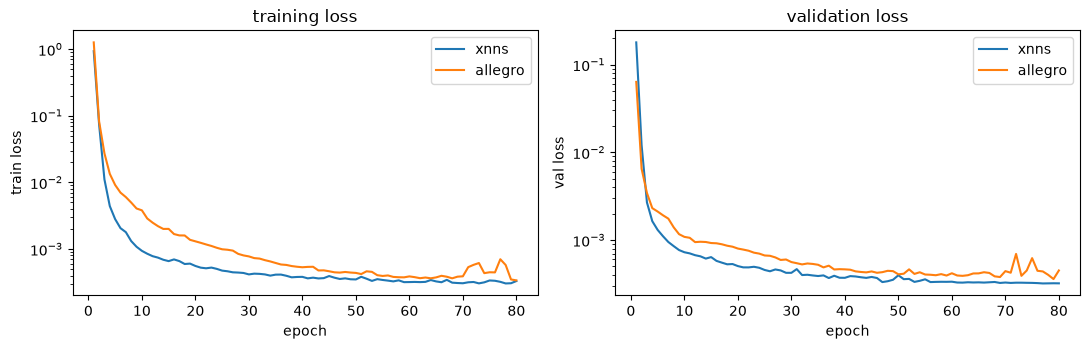

training time:  xnns 297s   allegro 120s


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ep = range(1, EPOCHS + 1)
for a, key, ttl in [(ax[0], "train", "training loss"), (ax[1], "val", "validation loss")]:
    a.plot(ep, hist_x[key], label="xnns"); a.plot(ep, hist_a[key], label="allegro")
    a.set_yscale("log"); a.set_xlabel("epoch"); a.set_ylabel(key + " loss")
    a.legend(); a.set_title(ttl)
plt.tight_layout(); plt.savefig("argon_loss_curves.png", dpi=120); plt.show()
print(f"training time:  xnns {t_x:.0f}s   allegro {t_a:.0f}s")

## 5. Evaluate both trained models on the held-out test set


In [9]:
def eval_xnns(model):
    model.eval(); Ep, Er, na, Fp, Fr = [], [], [], [], []
    for s, i in zip(test_structs, range(len(xnns_test))):
        out = model(xnns_test[i].to(DEVICE))
        Ep.append(float(out["energy"].detach())); Er.append(s["energy"]); na.append(len(s["atomic_numbers"]))
        Fp.append(out["forces"].detach().cpu().numpy()); Fr.append(s["forces"])
    return map(np.array, (Ep, Er, na)), np.concatenate(Fp), np.concatenate(Fr)

def eval_allegro(model):
    model.eval(); Ep, Er, na, Fp, Fr = [], [], [], [], []
    for s, d in zip(test_structs, al_test):
        b = next(iter(NequipDataLoader([d], batch_size=1))).to(DEVICE)
        out = model(AtomicData.to_AtomicDataDict(b))
        Ep.append(float(out["total_energy"].sum().detach())); Er.append(s["energy"]); na.append(len(s["atomic_numbers"]))
        Fp.append(out["forces"].detach().cpu().numpy()); Fr.append(s["forces"])
    return map(np.array, (Ep, Er, na)), np.concatenate(Fp), np.concatenate(Fr)

def metrics(EpErNa, Fp, Fr):
    Ep, Er, na = EpErNa
    e = (Ep - Er) / na * 1000.0; f = (Fp - Fr) * 1000.0
    return dict(e_rmse=np.sqrt((e**2).mean()), e_mae=np.abs(e).mean(),
                f_rmse=np.sqrt((f**2).mean()), f_mae=np.abs(f).mean(),
                Ep=Ep/na, Er=Er/na, Fp=Fp, Fr=Fr)

res_x = metrics(*eval_xnns(trainer.model))
res_a = metrics(*eval_allegro(al_model))
print(f"{'metric':<24}{'xnns':>10}{'original Allegro':>18}")
print("-" * 52)
for k, lbl in [("e_rmse", "energy RMSE [meV/atom]"), ("e_mae", "energy MAE  [meV/atom]"),
               ("f_rmse", "force  RMSE [meV/Å]"), ("f_mae", "force  MAE  [meV/Å]")]:
    print(f"{lbl:<24}{res_x[k]:>10.2f}{res_a[k]:>18.2f}")

metric                        xnns  original Allegro
----------------------------------------------------
energy RMSE [meV/atom]       15.81             17.37
energy MAE  [meV/atom]       11.66             11.57
force  RMSE [meV/Å]           1.67              2.08
force  MAE  [meV/Å]           1.07              1.47


### Side-by-side parity plots


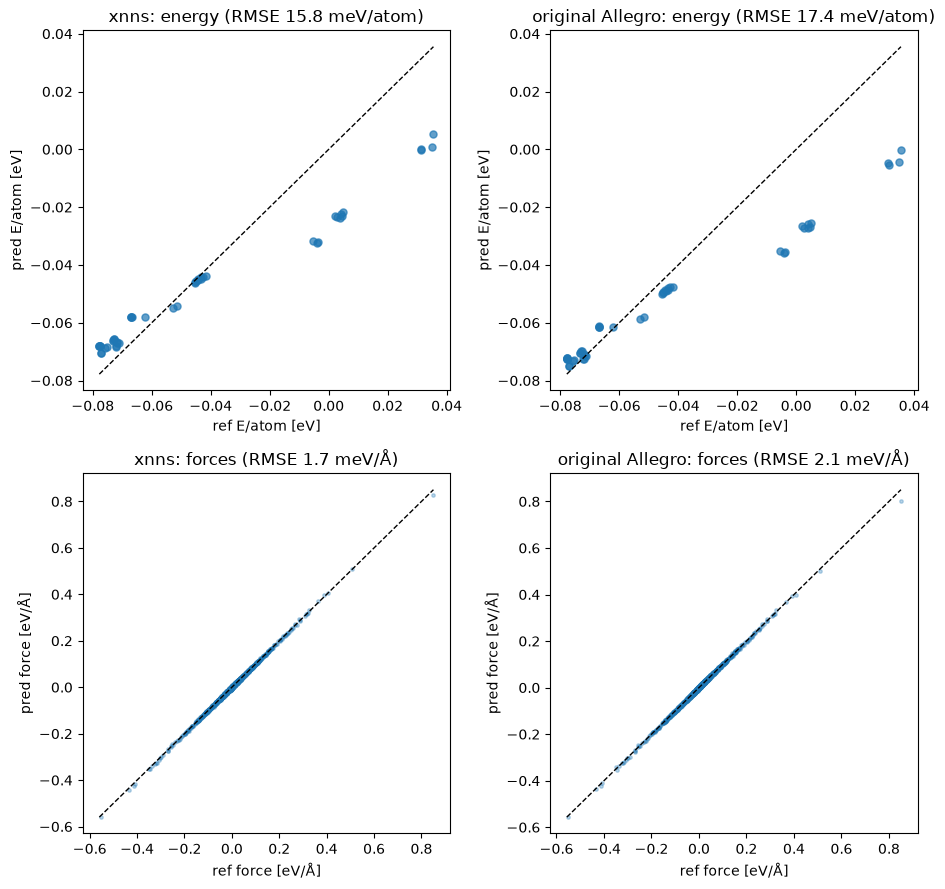

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(9.5, 9))
rng = np.random.default_rng(0)
idx = rng.choice(res_x["Fr"].size, size=4000, replace=False)
for col, (res, name) in enumerate([(res_x, "xnns"), (res_a, "original Allegro")]):
    a0 = ax[0, col]
    lim = [min(res["Er"].min(), res["Ep"].min()), max(res["Er"].max(), res["Ep"].max())]
    a0.plot(lim, lim, "k--", lw=1); a0.scatter(res["Er"], res["Ep"], s=26, alpha=0.7)
    a0.set_xlabel("ref E/atom [eV]"); a0.set_ylabel("pred E/atom [eV]")
    a0.set_title(f"{name}: energy (RMSE {res['e_rmse']:.1f} meV/atom)")
    a1 = ax[1, col]
    fr, fp = res["Fr"].ravel()[idx], res["Fp"].ravel()[idx]
    lim = [min(fr.min(), fp.min()), max(fr.max(), fp.max())]
    a1.plot(lim, lim, "k--", lw=1); a1.scatter(fr, fp, s=6, alpha=0.3)
    a1.set_xlabel("ref force [eV/Å]"); a1.set_ylabel("pred force [eV/Å]")
    a1.set_title(f"{name}: forces (RMSE {res['f_rmse']:.1f} meV/Å)")
plt.tight_layout(); plt.savefig("argon_parity_xnns_vs_allegro.png", dpi=120); plt.show()

## 6. `xnns` ASE calculator (deployment)


In [11]:
from ase import Atoms
from xnns.common.deploy import XNNSCalculator

s = test_structs[0]
atoms = Atoms(numbers=s["atomic_numbers"], positions=s["pos"], cell=s["cell"], pbc=True)
atoms.calc = XNNSCalculator(trainer.model.to("cpu"), cutoff=CUTOFF)
print(f"ASE single point: E = {atoms.get_potential_energy():.4f} eV | "
      f"max|F| = {np.abs(atoms.get_forces()).max():.4f} eV/Å")
print(f"reference       : E = {s['energy']:.4f} eV")

ASE single point: E = -27.1625 eV | max|F| = 0.0874 eV/Å
reference       : E = -31.0395 eV


## Summary: every stage compared

| stage | result |
|---|---|
| **Data → graphs** | identical edge sets in both pipelines |
| **Model build** | identical architecture; parameter counts match except xnns's 200-entry `atom_ref` table |
| **Same function?** | weight transplant → **identical E and F on periodic Argon** (float32 round-off) |
| **Training** | same data / loss / optimiser / schedule → comparable loss curves |
| **Test accuracy** | energy and force RMSE/MAE agree between the two implementations |

The `xnns` Allegro is a faithful, dependency-light (only `e3nn`)
re-implementation of the original Allegro; residual metric differences come
only from independent initialisation and shuffling. The companion notebook
`allegro_argon_density_md.ipynb` runs NPT MD with both codes.
